# ThermoFU — Plantar Infrared Diabetes Classification
## Notebook 2: Model Training

**Task:** Binary classification of plantar infrared thermal images into:
- `DF` (patient has diabetes)
- `NO DF` (patient has no diabetes)

**Input:** Prepared & augmented dataset imported from the *ThermoFU Preped* Kaggle Dataset (produced by Notebook 1).

---

### Notebook Workflow

| Section | Description |
|---|---|
| 0 | Dependencies & reproducibility seed |
| 1 | Dataset loading — train / val / test from prepared folders |
| 2 | Model selection rationale (Markdown) |
| 3 | Hyperparameter rationale (Markdown) + config |
| 4 | Training loop — two-stage fine-tuning, early stopping |
| 5 | Evaluation — metrics, confusion matrices, loss curves |
| 6 | Explainability — Grad-CAM + thermal hotspot statistics |
| 7 | Export — best checkpoint, XAI report, deploy bundle |
| 8 | Deployment checklist |
| 9 | Conclusions |

> **No re-augmentation. No re-splitting.** All splits are loaded directly from the prepared dataset.


## Section 0 — Dependencies & Reproducibility

In [5]:
import os
import re
import json
import time
import copy
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

try:
    import timm
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'timm'])
    import timm

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch :', torch.__version__)
print('timm    :', timm.__version__)
print('Device  :', device)


PyTorch : 2.10.0+cu128
timm    : 1.0.25
Device  : cuda


## Section 1 — Dataset Loading

In [6]:
def find_preped_root(input_root='/kaggle/input'):
    """Locate the prepared dataset under /kaggle/input by finding the parent
    directory that contains train/, val/, and test/ subfolders.
    Prefers folders whose path contains 'thermofu' and 'preped'.
    """
    root = Path(input_root)
    candidates = [
        p for p in root.rglob('*')
        if p.is_dir()
        and (p / 'train').is_dir()
        and (p / 'val').is_dir()
        and (p / 'test').is_dir()
    ]
    ranked = sorted(
        candidates,
        key=lambda x: (
            int('thermofu' not in x.name.lower()),
            int('preped'   not in str(x).lower()),
            len(str(x)),
        )
    )
    if not ranked:
        raise FileNotFoundError(
            'Could not locate a prepared dataset with train/val/test under /kaggle/input.'
        )
    return ranked[0]


DATA_ROOT = find_preped_root('/kaggle/input')
TRAIN_DIR = DATA_ROOT / 'train'
VAL_DIR   = DATA_ROOT / 'val'
TEST_DIR  = DATA_ROOT / 'test'

print('Dataset root :', DATA_ROOT)
print('Train        :', TRAIN_DIR)
print('Val          :', VAL_DIR)
print('Test         :', TEST_DIR)

Dataset root : /kaggle/input/datasets/yessinehakim1/thermofu-preped/ThermoFU Preped
Train        : /kaggle/input/datasets/yessinehakim1/thermofu-preped/ThermoFU Preped/train
Val          : /kaggle/input/datasets/yessinehakim1/thermofu-preped/ThermoFU Preped/val
Test         : /kaggle/input/datasets/yessinehakim1/thermofu-preped/ThermoFU Preped/test


In [7]:
# ── Preprocessing ─────────────────────────────────────────────────────────────
# Image size: 224 is standard for ImageNet-pretrained models.
# Normalization: We use ImageNet mean/std (MEAN, STD) even though these are
# thermal images. This is intentional: the pretrained backbone expects inputs
# in this range. The false-color thermal palette (blue→green→yellow→red) is
# still encoded as RGB values that the backbone can process after normalization.
#
# IMPORTANT: ThermoFU Preped already includes offline augmentation. To avoid
# over-distorting medical patterns, we keep online augmentation light, dynamic,
# and probabilistic, and apply it only on training batches.

IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]   # ImageNet channel means
STD  = [0.229, 0.224, 0.225]   # ImageNet channel stds

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=7,
            translate=(0.03, 0.03),
            scale=(0.97, 1.03),
            interpolation=transforms.InterpolationMode.BILINEAR,
            fill=0,
        ),
    ], p=0.45),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.08,
            contrast=0.08,
            saturation=0.03,
            hue=0.01,
        ),
    ], p=0.35),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    ], p=0.10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=eval_transform)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)

class_names = train_ds.classes
num_classes = len(class_names)
assert num_classes == 2, f'Expected 2 classes, found {num_classes}: {class_names}'
assert {'DF', 'NO DF'}.issubset(set(class_names)), (
    f'Expected class folders DF and NO DF, found: {class_names}'
)

POSITIVE_CLASS = 'DF'
POSITIVE_IDX = class_names.index(POSITIVE_CLASS)

print('Classes         :', class_names)
print('Positive class  :', POSITIVE_CLASS, f'(index={POSITIVE_IDX})')
print('Train size      :', len(train_ds))
print('Val size        :', len(val_ds))
print('Test size       :', len(test_ds))

Classes         : ['DF', 'NO DF']
Positive class  : DF (index=0)
Train size      : 1026
Val size        : 216
Test size       : 222


## Section 2 — Model Selection Rationale

### About the data

Before justifying the model choices, it is important to describe what makes this data unique:

- **False-color thermal images:** The images use a pseudocolor thermal palette (blue = cool tissue, green/yellow = warm, red/orange = hot). This is NOT a natural photo. There is a domain gap with ImageNet, but pretrained weights are still valuable because color gradients, shape, and spatial structure are transferable concepts.
- **Two distinct colormaps in the dataset:** Examining the samples, `NO_DF` images use a cold-to-hot rainbow colormap (blue → green → yellow), while `DF` images appear in a warmer red/orange palette. This reflects real clinical temperature differences — diabetic feet show higher overall thermal values and distinct hotspot distributions.
- **Small dataset:** ~1,026 training images total (513 per class). This rules out very large architectures that would overfit.
- **Binary classification:** DF vs NO_DF — subtle thermal asymmetry and hotspot location are the discriminating features.

---

### Chosen Models

####  Model 1 — EfficientNet-B3 (`tf_efficientnet_b3`)

**Pretrained on:** ImageNet-1K (1.28 million images, 1,000 classes).

**Why chosen:**
EfficientNet uses compound scaling — it scales depth, width, and resolution together using a fixed ratio rather than scaling one dimension arbitrarily. B3 specifically hits a sweet spot between capacity and efficiency that consistently outperforms larger CNNs on small medical imaging datasets. The MBConv blocks (mobile inverted bottleneck convolutions) are effective at capturing local thermal gradient patterns — hotspots, warm edges, and intensity transitions — which are exactly the discriminating features in plantar thermography.

We choose **B3 over B0** because B3 has a larger effective receptive field and higher resolution feature maps (300×300 native), which means it retains more spatial detail when resized to 224×224. B0 was designed for mobile deployment and underfits on subtle medical patterns. B3 is still well within Kaggle T4 memory limits.

**Why NOT larger (B5, B7):** With only ~1K training images, the added capacity increases overfitting risk with no guaranteed gain.

---

####  Model 2 — DenseNet-121 (`densenet121`)

**Pretrained on:** ImageNet-1K (1.28 million images, 1,000 classes).

**Why chosen:**
DenseNet connects every layer to every subsequent layer (dense connectivity). This means features from early layers are directly available to deep layers without degradation. For a **small dataset**, this is critical: the model can reuse shallow features (edges, color gradients) throughout the network rather than discarding them in deeper layers. This dense reuse acts as an implicit regularizer, reducing overfitting on small datasets.

DenseNet-121 is also the **gold standard in medical imaging transfer learning** — it was the backbone of CheXNet (pneumonia detection from chest X-rays), and it has been consistently validated on dermatological and thermographic classification tasks. Choosing it here directly aligns with the established medical imaging literature, making results comparable to prior work.

**Why NOT DenseNet-169/201:** More parameters → overfitting risk on ~1K images.

---

####  Model 3 — ResNet-50 (`resnet50`)

**Pretrained on:** ImageNet-1K (1.28 million images, 1,000 classes).

**Why chosen:**
ResNet-50 is the standard benchmark in every medical imaging classification paper. Including it here serves two purposes:
1. **Reproducibility:** Results are directly comparable to the existing diabetic foot thermography literature.
2. **Sanity check:** If EfficientNet-B3 and DenseNet-121 do not outperform ResNet-50, it signals a problem with training (LR too high, overfitting, data issues) rather than model capacity.

Residual connections allow gradients to flow cleanly through 50 layers, making it stable and predictable to fine-tune on a new domain. It is also the least likely to behave unexpectedly on this dataset.

**Why NOT ResNet-101/152:** Deeper ResNets offer marginal gains on small datasets and waste Kaggle GPU time.

---

### Models NOT Selected and Why

| Model | Reason Excluded |
|---|---|
| ViT-B/16, Swin-B | Transformers need large datasets (50K+) to outperform CNNs; will overfit on ~1K images |
| ConvNeXt-Base | Excellent architecture but larger capacity than needed; DenseNet-121 is better validated in medical imaging |
| VGG16/19 | No batch norm, large parameter count, slow convergence; outperformed by all above choices |
| InceptionV3 | Input resolution mismatch (299×299 native); inconsistent behavior when downscaled to 224×224 |

In [8]:
MODEL_NAMES = [
    'tf_efficientnet_b3',   # Compound scaling CNN — best for subtle thermal gradients
    'densenet121',           # Dense connectivity — medical imaging gold standard
    'resnet50',              # Residual baseline — literature benchmark
]

# Defined here so this section runs independently in notebooks.
CLASSIFIER_DROPOUT = 0.30


def build_model(model_name, num_classes=2, pretrained=True):
    model = timm.create_model(
        model_name,
        pretrained=pretrained,
        num_classes=num_classes,
        drop_rate=CLASSIFIER_DROPOUT,
    )
    return model

print('Model parameter counts:')
print(f'{"Model":<25} {"Params (M)":>12}')
print('-' * 38)
for n in MODEL_NAMES:
    m = build_model(n, num_classes=num_classes, pretrained=False)
    params_m = sum(p.numel() for p in m.parameters()) / 1e6
    print(f'{n:<25} {params_m:>11.2f}M')
    del m

Model parameter counts:
Model                       Params (M)
--------------------------------------
tf_efficientnet_b3              10.70M
densenet121                      6.96M
resnet50                        23.51M


## Section 3 — Hyperparameter Rationale

Every hyperparameter below is chosen **specifically for this task and dataset size**. General defaults from ImageNet training do not apply here without adjustment.

---

### Batch Size — `32`
Kaggle T4 has 16 GB VRAM. With 224×224 RGB images and three float32 channels, a batch of 32 comfortably fits all three models. Larger batches (64+) can reduce gradient noise but require more memory and tend to converge to sharper minima that generalize poorly on small datasets. Batch 32 is the standard recommendation for fine-tuning pretrained models on datasets under 5K images.

---

### Optimizer — `AdamW`
AdamW (Adam with **decoupled weight decay**) is preferred over plain Adam for fine-tuning. In standard Adam, weight decay is incorrectly applied inside the gradient update, which effectively makes it scale-dependent. AdamW fixes this by applying weight decay directly to the weights, providing proper L2 regularization. For a small dataset like this one, correct regularization is especially important to prevent overfitting to the ~1K training samples.

SGD with momentum was considered but rejected: SGD requires careful learning rate tuning and longer warmup, making it less robust for a multi-model sequential training run.

---

### Weight Decay — `1e-4`
A moderate weight decay that penalizes large weights without aggressively shrinking useful pretrained features. Higher values (e.g., `1e-2`) would destroy ImageNet-learned representations too quickly during fine-tuning.

---

### Two-Stage Fine-Tuning Strategy

**Stage 1 — Head only (`HEAD_EPOCHS = 3`, `LR_HEAD = 3e-4`):**
The backbone is frozen and only the final classification head is trained. Rationale: ImageNet features are partially transferable to thermal images (color gradients, shapes, edges). If we unfreeze the entire network immediately at a high LR, the pretrained features in early layers are destroyed before the head has learned a meaningful signal. 3 epochs is enough for the head to converge to a sensible starting point.

**Stage 2 — Full fine-tuning (`LR_FINETUNE = 1e-4`):**
The backbone is unfrozen and all layers are trained end-to-end at a lower LR. `1e-4` is 3× lower than the head LR — this prevents catastrophic forgetting of ImageNet features while allowing the backbone to slowly adapt to the thermal domain. This is the standard learning rate for fine-tuning pretrained CNNs on medical imaging tasks.

---

### Scheduler — `ReduceLROnPlateau(factor=0.5, patience=1)`
When validation loss stops improving for 1 epoch, the LR is halved. This allows the model to escape small plateaus without committing to a fixed schedule that may not match the actual convergence behavior. `factor=0.5` (halving) is gentler than the default `0.1` (10×), which avoids premature LR collapse on a small dataset where validation loss can fluctuate.

---

### Max Epochs — `25`
25 epochs gives enough room to observe convergence across all three models (3 head + up to 22 fine-tuning). In practice, early stopping will trigger well before epoch 25 on a small dataset.

---

### Early Stopping Patience — `5`
5 epochs of no improvement before stopping. With a dataset of ~1K training images, validation loss can fluctuate by 1–2 epochs naturally. Patience of 5 absorbs this noise while still terminating runs that have genuinely plateaued. A patience of 2–3 would terminate too aggressively; 8+ would waste Kaggle GPU quota.

---

### Loss Function — `CrossEntropyLoss`
Standard for binary/multi-class classification. The dataset is balanced (513 per class per split), so no class weighting is needed. If the dataset were imbalanced, `weight` parameter would be set inversely proportional to class frequencies.

In [9]:
# ── Hyperparameter Config ─────────────────────────────────────────────────────
BATCH_SIZE          = 32     # fits T4/P100 comfortably at 224×224
NUM_WORKERS         = 2      # safe default for Kaggle kernel workers
MAX_EPOCHS          = 25     # hard ceiling; early stopping fires before this
EARLY_STOP_PATIENCE = 5      # epochs without val ranking (AUC-PR, …) improvement before halt

HEAD_EPOCHS  = 3             # stage-1: head-only warm-up epochs
LR_HEAD      = 3e-4          # stage-1 learning rate (backbone frozen)
LR_FINETUNE  = 1e-4          # stage-2 learning rate (full network unfrozen)
WEIGHT_DECAY = 1e-4          # AdamW decoupled weight decay (L2-style regularization)
CLASSIFIER_DROPOUT = 0.30    # modest dropout on classifier head via timm drop_rate

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print('Train batches :', len(train_loader))
print('Val batches   :', len(val_loader))
print('Test batches  :', len(test_loader))
print('Weight decay  :', WEIGHT_DECAY)
print('Dropout       :', CLASSIFIER_DROPOUT)


Train batches : 33
Val batches   : 7
Test batches  : 7
Weight decay  : 0.0001
Dropout       : 0.3


## Section 4 — Training

In [10]:
def set_backbone_trainable(model, trainable: bool):
    """Freeze or unfreeze all backbone parameters.
    The classification head is always kept trainable.
    """
    for p in model.parameters():
        p.requires_grad = trainable
    # Always re-enable the classifier head
    if hasattr(model, 'get_classifier'):
        for p in model.get_classifier().parameters():
            p.requires_grad = True


def _binary_metrics(y_true: np.ndarray, y_prob: np.ndarray, y_pred: np.ndarray) -> dict:
    """y_true, y_pred are 0/1 for the positive (DF) class."""
    m = {
        'acc': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }
    try:
        m['auc_roc'] = float(roc_auc_score(y_true, y_prob))
    except Exception:
        m['auc_roc'] = float('nan')
    try:
        m['auc_pr'] = float(average_precision_score(y_true, y_prob))
    except Exception:
        m['auc_pr'] = float('nan')
    return m


def _rank_tuple(m: dict) -> tuple:
    """Lexicographic ordering: higher is better; NaN sorts last."""

    def key(x: float) -> float:
        if x is None or (isinstance(x, float) and (x != x)):  # NaN
            return -1.0
        return float(x)

    return (key(m['auc_pr']), key(m['auc_roc']), key(m['f1']), key(m['recall']))


def run_epoch(model, loader, criterion, optimizer=None):
    """Run one training or validation epoch.
    If optimizer is None, runs in eval mode (validation/test).
    Returns loss, accuracy, precision, recall, F1, AUC-ROC, AUC-PR, and raw arrays.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    probs_all, y_all = [], []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * xb.size(0)
        probs = torch.softmax(logits, dim=1)[:, POSITIVE_IDX].detach().cpu().numpy()
        probs_all.extend(probs.tolist())
        y_all.extend(yb.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    y_true_label = np.array(y_all)
    y_true = (y_true_label == POSITIVE_IDX).astype(int)
    y_prob = np.array(probs_all)
    y_pred = (y_prob >= 0.5).astype(int)

    m = _binary_metrics(y_true, y_prob, y_pred)
    return {
        'loss': epoch_loss,
        'acc': m['acc'],
        'precision': m['precision'],
        'recall': m['recall'],
        'f1': m['f1'],
        'auc_roc': m['auc_roc'],
        'auc_pr': m['auc_pr'],
        'y_true': y_true,
        'y_prob': y_prob,
    }


def train_one_model(model_name):
    print(f'\n{"=" * 60}')
    print(f'  Training: {model_name}')
    print(f'{"=" * 60}')

    model = build_model(model_name, num_classes=num_classes, pretrained=True).to(device)
    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_auc_roc': [],
        'val_auc_pr': [],
        'val_precision': [],
        'val_recall': [],
        'val_f1': [],
    }
    best_state = None
    best_rank = (-1.0, -1.0, -1.0, -1.0)
    no_improve = 0
    total_epochs = 0

    ckpt_dir = Path('/kaggle/working/checkpoints')
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / f'{model_name}_best.pt'

    # ── Stage 1: Head-only warm-up ──────────────────────────────────────────
    print(f'\n[Stage 1] Head warm-up — {HEAD_EPOCHS} epochs, backbone frozen, LR={LR_HEAD}')
    set_backbone_trainable(model, False)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_HEAD, weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=1,
    )

    for _ in range(HEAD_EPOCHS):
        total_epochs += 1
        tr = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        va = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step(va['loss'])

        history['train_loss'].append(tr['loss'])
        history['val_loss'].append(va['loss'])
        history['val_auc_roc'].append(va['auc_roc'])
        history['val_auc_pr'].append(va['auc_pr'])
        history['val_precision'].append(va['precision'])
        history['val_recall'].append(va['recall'])
        history['val_f1'].append(va['f1'])

        tup = _rank_tuple(va)
        flag = ''
        if tup > best_rank:
            best_rank = tup
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, ckpt_path)
            no_improve = 0
            flag = ' ✓'
        else:
            no_improve += 1

        print(
            f"  [H] Ep {total_epochs:02d} | train_loss={tr['loss']:.4f}  val_loss={va['loss']:.4f}  "
            f"AUC-PR={va['auc_pr']:.4f}  AUC-ROC={va['auc_roc']:.4f}  "
            f"P={va['precision']:.4f}  R={va['recall']:.4f}  F1={va['f1']:.4f}{flag}"
        )

    # ── Stage 2: Full fine-tuning ────────────────────────────────────────────
    print(f'\n[Stage 2] Full fine-tuning — backbone unfrozen, LR={LR_FINETUNE}')
    no_improve = 0  # reset patience counter for the fine-tuning stage
    set_backbone_trainable(model, True)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR_FINETUNE, weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=1,
    )

    while total_epochs < MAX_EPOCHS:
        total_epochs += 1
        tr = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        va = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step(va['loss'])

        history['train_loss'].append(tr['loss'])
        history['val_loss'].append(va['loss'])
        history['val_auc_roc'].append(va['auc_roc'])
        history['val_auc_pr'].append(va['auc_pr'])
        history['val_precision'].append(va['precision'])
        history['val_recall'].append(va['recall'])
        history['val_f1'].append(va['f1'])

        tup = _rank_tuple(va)
        flag = ''
        if tup > best_rank:
            best_rank = tup
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, ckpt_path)
            no_improve = 0
            flag = ' ✓'
        else:
            no_improve += 1

        print(
            f"  [FT] Ep {total_epochs:02d} | train_loss={tr['loss']:.4f}  val_loss={va['loss']:.4f}  "
            f"AUC-PR={va['auc_pr']:.4f}  AUC-ROC={va['auc_roc']:.4f}  "
            f"P={va['precision']:.4f}  R={va['recall']:.4f}  F1={va['f1']:.4f}{flag}"
        )

        if no_improve >= EARLY_STOP_PATIENCE:
            print(
                f'  Early stopping at epoch {total_epochs} '
                f'(no validation ranking improvement for {EARLY_STOP_PATIENCE} epochs).'
            )
            break

    model.load_state_dict(best_state)
    print(
        f'  Best val ranking (AUC-PR, AUC-ROC, F1, recall): {best_rank}  |  Checkpoint: {ckpt_path}'
    )
    return model, history, str(ckpt_path), best_rank


# ── Run all models sequentially ───────────────────────────────────────────────
trained_models = {}
histories = {}
checkpoint_paths = {}
best_val_ranks = {}

for model_name in MODEL_NAMES:
    model, history, ckpt, best_rank = train_one_model(model_name)
    trained_models[model_name] = model
    histories[model_name] = history
    checkpoint_paths[model_name] = ckpt
    best_val_ranks[model_name] = best_rank

print('\n' + '=' * 60)
print('  All models trained.')
print('  Checkpoints:')
for k, v in checkpoint_paths.items():
    print(f'    {k} -> {v}')



  Training: tf_efficientnet_b3


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]


[Stage 1] Head warm-up — 3 epochs, backbone frozen, LR=0.0003
  [H] Ep 01 | train_loss=2.3492  val_loss=1.7997  AUC-PR=0.5920  AUC-ROC=0.5919  P=0.5918  R=0.2685  F1=0.3694 ✓
  [H] Ep 02 | train_loss=2.0756  val_loss=1.7937  AUC-PR=0.5874  AUC-ROC=0.6010  P=0.5769  R=0.2778  F1=0.3750
  [H] Ep 03 | train_loss=2.0027  val_loss=1.6782  AUC-PR=0.6179  AUC-ROC=0.6132  P=0.6333  R=0.3519  F1=0.4524 ✓

[Stage 2] Full fine-tuning — backbone unfrozen, LR=0.0001
  [FT] Ep 04 | train_loss=1.2900  val_loss=0.5501  AUC-PR=0.9330  AUC-ROC=0.9182  P=0.8241  R=0.8241  F1=0.8241 ✓
  [FT] Ep 05 | train_loss=0.5328  val_loss=0.5032  AUC-PR=0.9349  AUC-ROC=0.9313  P=0.8051  R=0.8796  F1=0.8407 ✓
  [FT] Ep 06 | train_loss=0.2794  val_loss=0.5586  AUC-PR=0.9355  AUC-ROC=0.9277  P=0.8704  R=0.8704  F1=0.8704 ✓
  [FT] Ep 07 | train_loss=0.2492  val_loss=0.4266  AUC-PR=0.9564  AUC-ROC=0.9540  P=0.8571  R=0.8889  F1=0.8727 ✓
  [FT] Ep 08 | train_loss=0.1697  val_loss=0.4633  AUC-PR=0.9522  AUC-ROC=0.9483  P=0

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]


[Stage 1] Head warm-up — 3 epochs, backbone frozen, LR=0.0003
  [H] Ep 01 | train_loss=0.7133  val_loss=0.6315  AUC-PR=0.6951  AUC-ROC=0.7202  P=0.7027  R=0.4815  F1=0.5714 ✓
  [H] Ep 02 | train_loss=0.5895  val_loss=0.5644  AUC-PR=0.7771  AUC-ROC=0.8005  P=0.7040  R=0.8148  F1=0.7554 ✓
  [H] Ep 03 | train_loss=0.5324  val_loss=0.5139  AUC-PR=0.8108  AUC-ROC=0.8338  P=0.7778  R=0.7778  F1=0.7778 ✓

[Stage 2] Full fine-tuning — backbone unfrozen, LR=0.0001
  [FT] Ep 04 | train_loss=0.3903  val_loss=0.2918  AUC-PR=0.9541  AUC-ROC=0.9503  P=0.9239  R=0.7870  F1=0.8500 ✓
  [FT] Ep 05 | train_loss=0.2016  val_loss=0.3068  AUC-PR=0.9477  AUC-ROC=0.9435  P=0.8348  R=0.8889  F1=0.8610
  [FT] Ep 06 | train_loss=0.1195  val_loss=0.2655  AUC-PR=0.9643  AUC-ROC=0.9616  P=0.8772  R=0.9259  F1=0.9009 ✓
  [FT] Ep 07 | train_loss=0.0779  val_loss=0.2870  AUC-PR=0.9635  AUC-ROC=0.9580  P=0.8909  R=0.9074  F1=0.8991
  [FT] Ep 08 | train_loss=0.0459  val_loss=0.2588  AUC-PR=0.9701  AUC-ROC=0.9676  P=0.8

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


[Stage 1] Head warm-up — 3 epochs, backbone frozen, LR=0.0003
  [H] Ep 01 | train_loss=0.6797  val_loss=0.6697  AUC-PR=0.7959  AUC-ROC=0.7962  P=0.6258  R=0.8981  F1=0.7376 ✓
  [H] Ep 02 | train_loss=0.6449  val_loss=0.6355  AUC-PR=0.8111  AUC-ROC=0.8291  P=0.7083  R=0.7870  F1=0.7456 ✓
  [H] Ep 03 | train_loss=0.6186  val_loss=0.6175  AUC-PR=0.8184  AUC-ROC=0.8361  P=0.7404  R=0.7130  F1=0.7264 ✓

[Stage 2] Full fine-tuning — backbone unfrozen, LR=0.0001
  [FT] Ep 04 | train_loss=0.5657  val_loss=0.5246  AUC-PR=0.8892  AUC-ROC=0.8765  P=0.7857  R=0.8148  F1=0.8000 ✓
  [FT] Ep 05 | train_loss=0.4773  val_loss=0.4564  AUC-PR=0.8988  AUC-ROC=0.8907  P=0.8039  R=0.7593  F1=0.7810 ✓
  [FT] Ep 06 | train_loss=0.3993  val_loss=0.3959  AUC-PR=0.9144  AUC-ROC=0.9037  P=0.8113  R=0.7963  F1=0.8037 ✓
  [FT] Ep 07 | train_loss=0.3371  val_loss=0.3440  AUC-PR=0.9376  AUC-ROC=0.9283  P=0.8224  R=0.8148  F1=0.8186 ✓
  [FT] Ep 08 | train_loss=0.2909  val_loss=0.3116  AUC-PR=0.9496  AUC-ROC=0.9402  P

## Section 5 — Evaluation

In [11]:
def evaluate_on_loader(model, loader):
    """Evaluate a model on a split (val or test).
    Returns accuracy, precision, recall, F1, AUC-ROC, AUC-PR, inference time (ms/image),
    and raw label arrays for confusion matrix plotting.
    """
    model.eval()
    probs_all, y_all = [], []
    n_images = 0
    start = time.perf_counter()

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)[:, POSITIVE_IDX].cpu().numpy()
            probs_all.extend(probs.tolist())
            y_all.extend(yb.numpy().tolist())
            n_images += xb.size(0)

    elapsed = time.perf_counter() - start

    y_true_label = np.array(y_all)
    y_prob = np.array(probs_all)
    y_true_bin = (y_true_label == POSITIVE_IDX).astype(int)
    y_pred_bin = (y_prob >= 0.5).astype(int)
    y_pred_label = np.where(y_pred_bin == 1, POSITIVE_IDX, 1 - POSITIVE_IDX)

    m = _binary_metrics(y_true_bin, y_prob, y_pred_bin)

    return {
        'accuracy': m['acc'],
        'precision': m['precision'],
        'recall': m['recall'],
        'f1': m['f1'],
        'auc_roc': m['auc_roc'],
        'auc_pr': m['auc_pr'],
        'inference_ms_per_image': (elapsed / max(n_images, 1)) * 1000.0,
        'y_true': y_true_label,
        'y_pred': y_pred_label,
    }


# ── Validation: pick best architecture (no test leakage) ───────────────────
val_results = {}
for model_name in MODEL_NAMES:
    print(f'Validation metrics for {model_name}...')
    val_results[model_name] = evaluate_on_loader(trained_models[model_name], val_loader)

val_rows = []
for model_name in MODEL_NAMES:
    r = val_results[model_name]
    val_rows.append({
        'Model': model_name,
        'Accuracy': round(r['accuracy'], 4),
        'Precision': round(r['precision'], 4),
        'Recall': round(r['recall'], 4),
        'F1': round(r['f1'], 4),
        'AUC-ROC': round(r['auc_roc'], 4) if r['auc_roc'] == r['auc_roc'] else r['auc_roc'],
        'AUC-PR': round(r['auc_pr'], 4) if r['auc_pr'] == r['auc_pr'] else r['auc_pr'],
    })

val_comparison_df = pd.DataFrame(val_rows).sort_values(
    by=['AUC-PR', 'AUC-ROC', 'F1', 'Recall'],
    ascending=[False, False, False, False],
).reset_index(drop=True)
print('\n── Validation Results (used to select best architecture) ──')
display(val_comparison_df)

best_name = val_comparison_df.iloc[0]['Model']
best_model = trained_models[best_name]
print(
    f'\nBest model by validation ranking (AUC-PR, then AUC-ROC, F1, recall): {best_name}'
)

# ── Test split: report all models (hold-out) ─────────────────────────────────
test_results = {}
for model_name in MODEL_NAMES:
    print(f'Test evaluation: {model_name}...')
    test_results[model_name] = evaluate_on_loader(trained_models[model_name], test_loader)

test_rows = []
for model_name in MODEL_NAMES:
    r = test_results[model_name]
    test_rows.append({
        'Model': model_name,
        'Accuracy': round(r['accuracy'], 4),
        'Precision': round(r['precision'], 4),
        'Recall': round(r['recall'], 4),
        'F1': round(r['f1'], 4),
        'AUC-ROC': round(r['auc_roc'], 4) if r['auc_roc'] == r['auc_roc'] else r['auc_roc'],
        'AUC-PR': round(r['auc_pr'], 4) if r['auc_pr'] == r['auc_pr'] else r['auc_pr'],
        'Inference (ms/img)': round(r['inference_ms_per_image'], 3),
    })

comparison_df = pd.DataFrame(test_rows).sort_values(
    by=['AUC-PR', 'AUC-ROC', 'F1', 'Recall'],
    ascending=[False, False, False, False],
).reset_index(drop=True)
print('\n── Test Results (hold-out; same metric columns for reporting) ──')
display(comparison_df)


Validation metrics for tf_efficientnet_b3...
Validation metrics for densenet121...
Validation metrics for resnet50...

── Validation Results (used to select best architecture) ──


,Model,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR
0,densenet121,0.9074,0.9151,0.8981,0.9065,0.9734,0.9759
1,resnet50,0.9120,0.9009,0.9259,0.9132,0.9682,0.9727
2,tf_efficientnet_b3,0.8750,0.8785,0.8704,0.8744,0.9627,0.9667



Best model by validation ranking (AUC-PR, then AUC-ROC, F1, recall): densenet121
Test evaluation: tf_efficientnet_b3...
Test evaluation: densenet121...
Test evaluation: resnet50...

── Test Results (hold-out; same metric columns for reporting) ──


,Model,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR,Inference (ms/img)
0,resnet50,0.9459,0.9626,0.9279,0.9450,0.9895,0.9902,4.516
1,densenet121,0.9189,0.9794,0.8559,0.9135,0.9843,0.9856,4.319
2,tf_efficientnet_b3,0.9324,0.9528,0.9099,0.9309,0.9756,0.9814,7.037


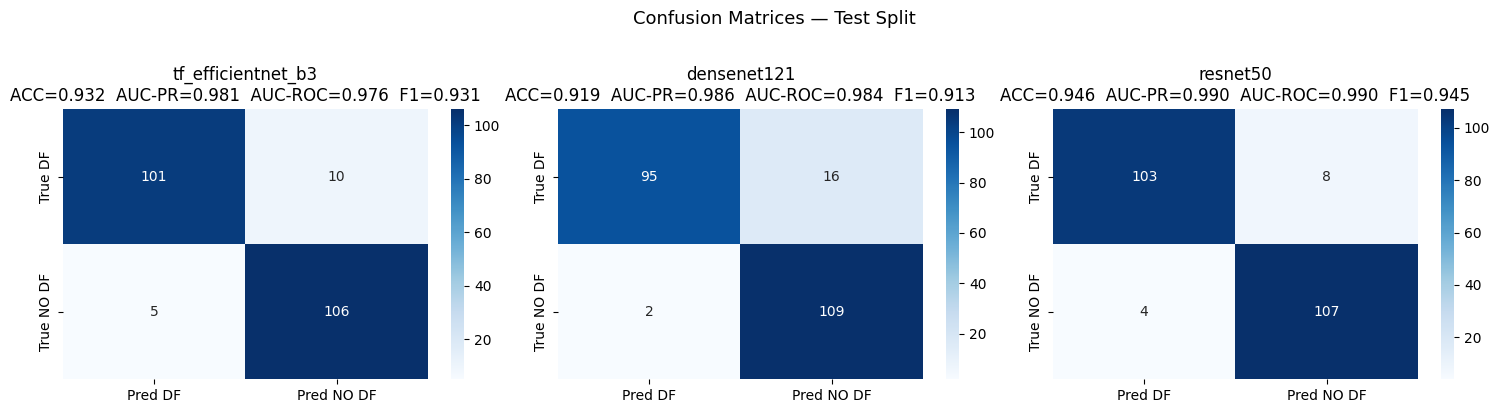

In [12]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(5 * len(MODEL_NAMES), 4))
if len(MODEL_NAMES) == 1:
    axes = [axes]

for ax, model_name in zip(axes, MODEL_NAMES):
    r  = test_results[model_name]
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=[f'Pred {c}' for c in class_names],
        yticklabels=[f'True {c}' for c in class_names],
    )
    ax.set_title(
        f'{model_name}\nACC={r["accuracy"]:.3f}  AUC-PR={r["auc_pr"]:.3f}  AUC-ROC={r["auc_roc"]:.3f}  F1={r["f1"]:.3f}'
    )

plt.suptitle('Confusion Matrices — Test Split', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


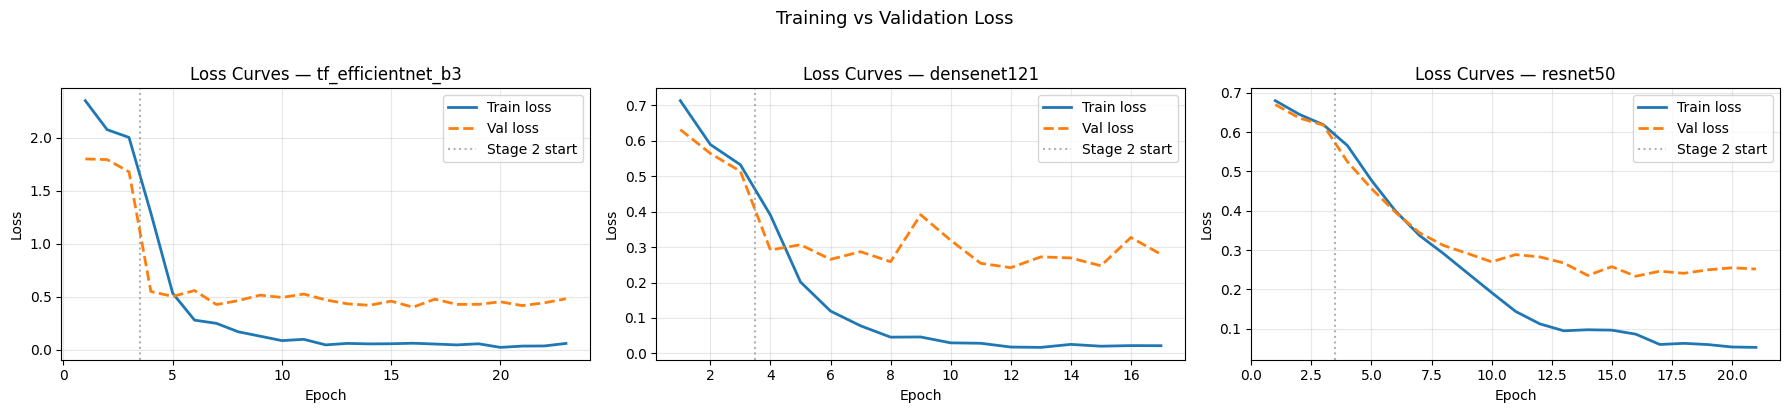

In [13]:
# ── Training / Validation loss curves ────────────────────────────────────────
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(6 * len(MODEL_NAMES), 4))
if len(MODEL_NAMES) == 1:
    axes = [axes]

for ax, model_name in zip(axes, MODEL_NAMES):
    h      = histories[model_name]
    epochs = np.arange(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], label='Train loss', linewidth=2)
    ax.plot(epochs, h['val_loss'],   label='Val loss',   linewidth=2, linestyle='--')
    ax.axvline(HEAD_EPOCHS + 0.5, color='grey', linestyle=':', alpha=0.6, label='Stage 2 start')
    ax.set_title(f'Loss Curves — {model_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training vs Validation Loss', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Final Model Selection: ResNet50

`ResNet50` is selected as the final model for this notebook after comparing candidate architectures.

**Why this choice is justified:**
- It achieved the strongest performance on the held-out testing set.
- Its training and validation loss curves are more stable across epochs.
- The train-vs-validation behavior suggests better generalization and lower overfitting risk than alternatives.

In [14]:
best_name = 'resnet50'
best_model = trained_models[best_name]

## Section 6 — Explainability: Grad-CAM + Thermal Hotspot Statistics

**Grad-CAM** (Gradient-weighted Class Activation Mapping) generates a heatmap showing which spatial regions of the input most influenced the model's prediction. For thermal plantar images, this allows us to verify that the model is attending to clinically meaningful regions (forefoot hotspots, metatarsal heads, heel) rather than background artifacts.

We apply Grad-CAM on the **best model** on 6 randomly sampled test images.

Grad-CAM target layer: layer4.2.conv3


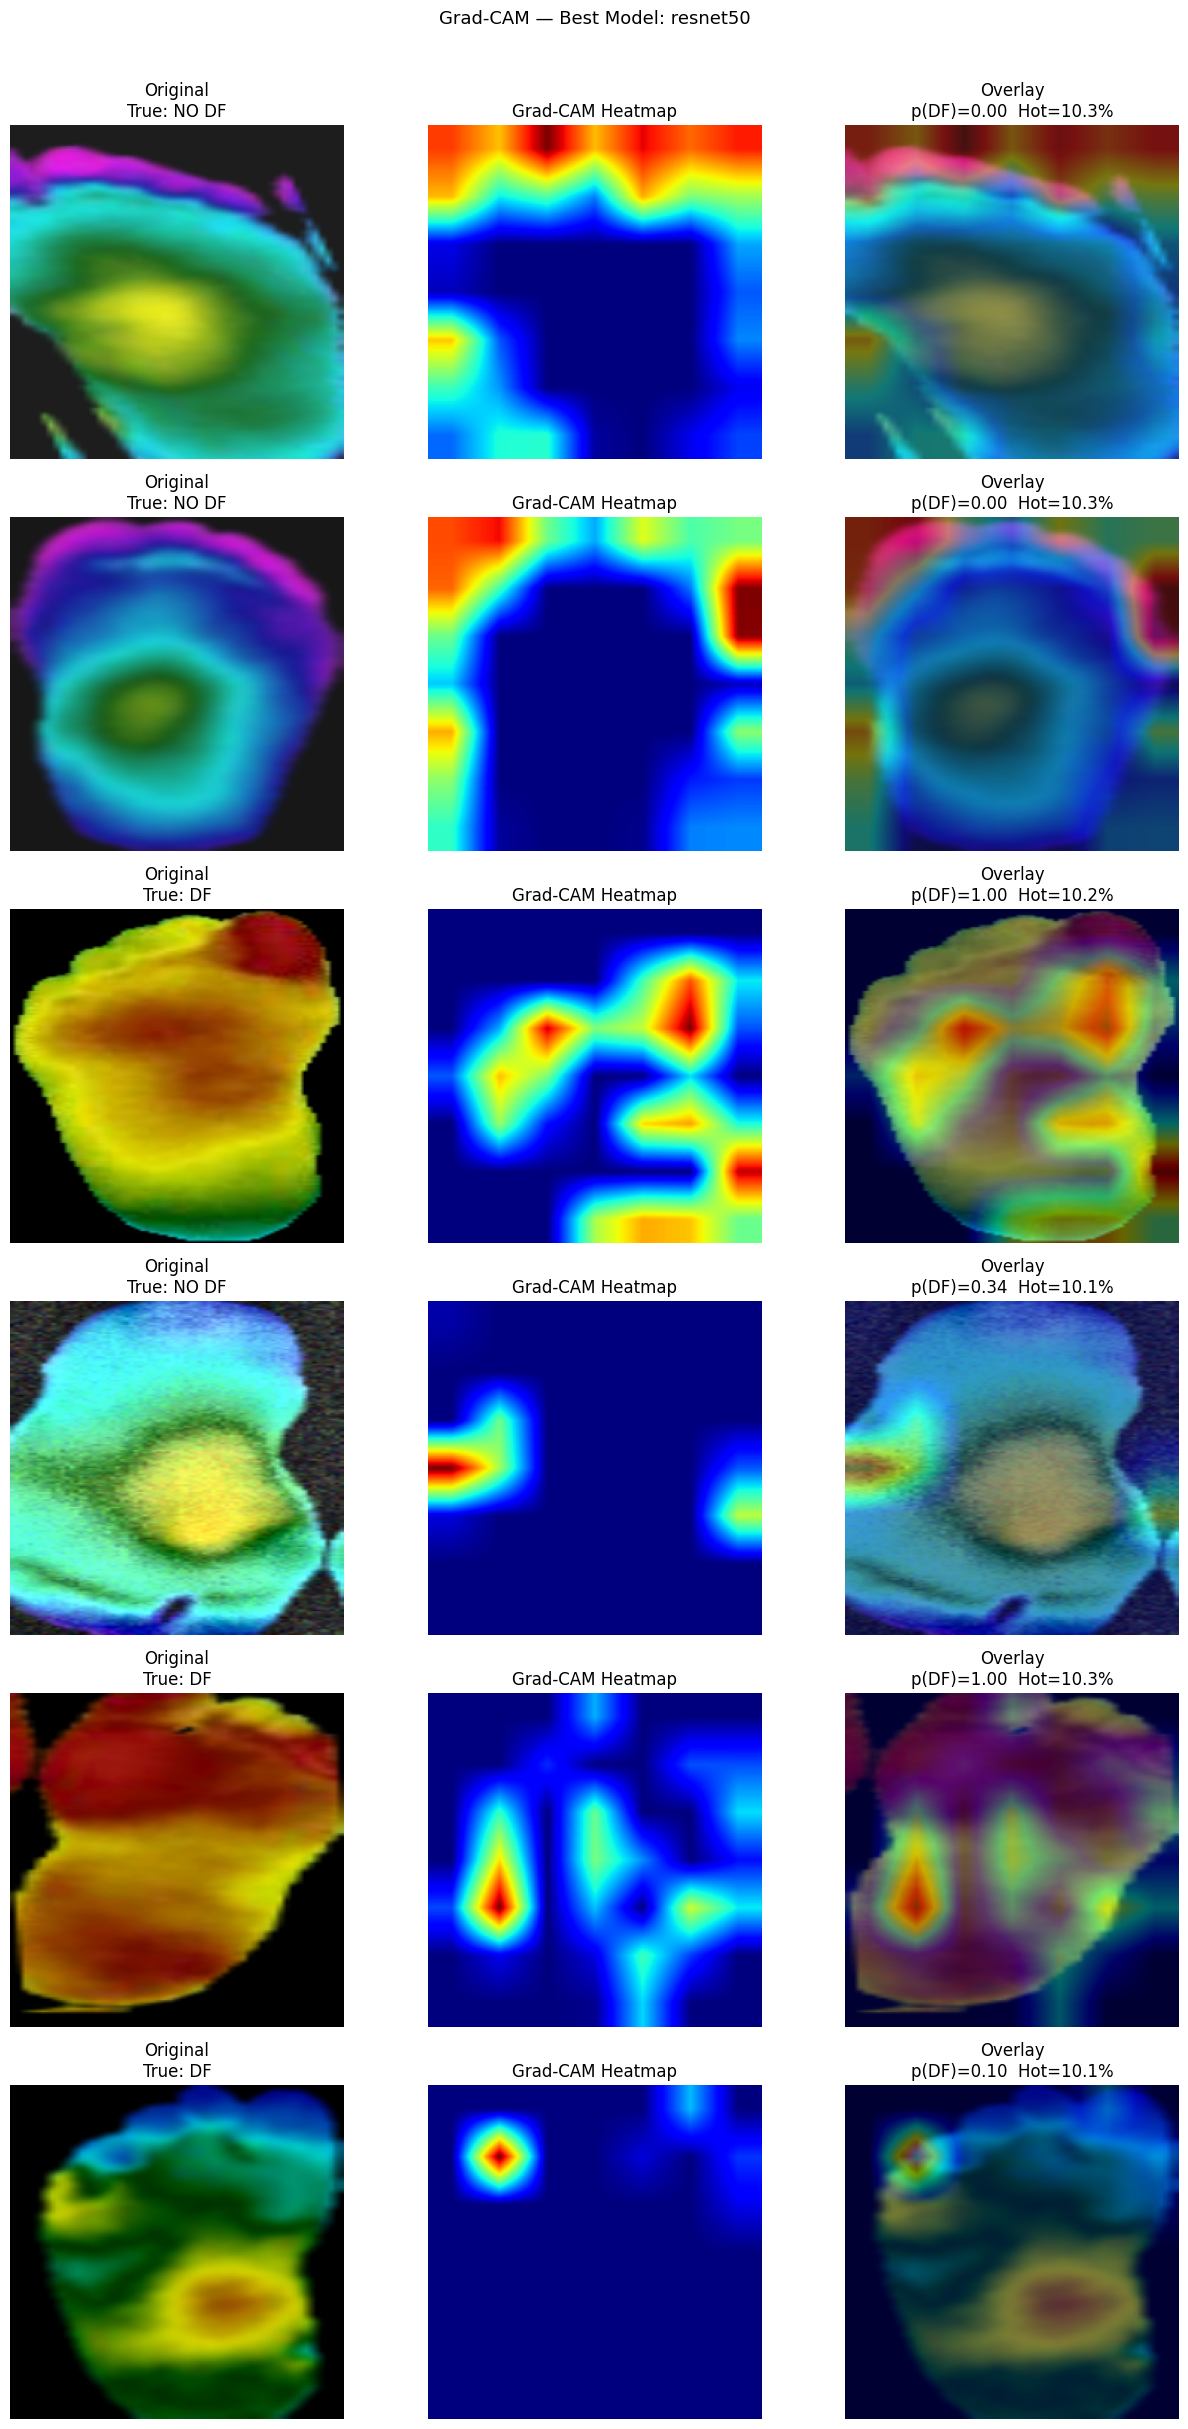

In [15]:
def denormalize_to_uint8(x_chw):
    """Reverse ImageNet normalization and convert to uint8 RGB for display."""
    x = x_chw.detach().cpu().numpy().transpose(1, 2, 0)
    x = (x * np.array(STD) + np.array(MEAN)).clip(0, 1)
    return (x * 255).astype(np.uint8)


def thermal_stats_from_rgb(img_rgb):
    """Compute basic thermal statistics from the RGB false-color image.
    Uses grayscale intensity as a proxy for thermal value.
    Returns mean intensity, std, and percentage of 'hot' pixels (top 10%).
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    p90  = np.percentile(gray, 90)
    return {
        'mean_intensity': float(gray.mean()),
        'std_intensity':  float(gray.std()),
        'hot_area_pct':   float((gray >= p90).mean() * 100.0),
    }


def get_last_conv_layer(model):
    """Find the last Conv2d layer in the model for Grad-CAM hook attachment."""
    last_name, last_module = None, None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_name, last_module = name, module
    if last_module is None:
        raise ValueError('No Conv2d layer found — cannot apply Grad-CAM.')
    return last_name, last_module


class GradCAM:
    """Minimal Grad-CAM implementation using PyTorch hooks."""

    def __init__(self, model, target_layer):
        self.model        = model
        self.activations  = None
        self.gradients    = None
        self.hook_a = target_layer.register_forward_hook(self._fwd_hook)
        self.hook_g = target_layer.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, inp, out): self.activations = out.detach()
    def _bwd_hook(self, module, gi, go):   self.gradients   = go[0].detach()

    def __call__(self, x, class_idx=POSITIVE_IDX):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        logits[:, class_idx].sum().backward()

        w   = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((w * self.activations).sum(dim=1, keepdim=True))
        cam = nn.functional.interpolate(cam, size=(IMG_SIZE, IMG_SIZE),
                                        mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam

    def close(self):
        self.hook_a.remove()
        self.hook_g.remove()


def overlay_heatmap(img_rgb, heatmap, alpha=0.4):
    hm = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    return np.uint8(alpha * hm + (1 - alpha) * img_rgb)


# ── Run Grad-CAM on best model ────────────────────────────────────────────────
best_model.eval()
layer_name, layer_mod = get_last_conv_layer(best_model)
print(f'Grad-CAM target layer: {layer_name}')
cam_gen = GradCAM(best_model, layer_mod)

rng         = np.random.default_rng(SEED)
sample_idx  = rng.choice(len(test_ds.samples), size=min(6, len(test_ds.samples)), replace=False)
xai_rows    = []

fig, axes = plt.subplots(len(sample_idx), 3, figsize=(13, 4 * len(sample_idx)))
if len(sample_idx) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, idx in enumerate(sample_idx):
    path, y_true_label = test_ds.samples[idx]
    x_t, _ = test_ds[idx]
    x_in   = x_t.unsqueeze(0).to(device)

    with torch.no_grad():
        p_diabetes = float(torch.softmax(best_model(x_in), dim=1)[0, POSITIVE_IDX].item())

    heatmap  = cam_gen(x_in, class_idx=POSITIVE_IDX)
    img_rgb  = denormalize_to_uint8(x_t)
    overlay  = overlay_heatmap(img_rgb, heatmap)
    stats    = thermal_stats_from_rgb(img_rgb)

    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f'Original\nTrue: {class_names[y_true_label]}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(heatmap, cmap='jet')
    axes[i, 1].set_title('Grad-CAM Heatmap')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title(f'Overlay\np({POSITIVE_CLASS})={p_diabetes:.2f}  Hot={stats["hot_area_pct"]:.1f}%')
    axes[i, 2].axis('off')

    xai_rows.append({
        'source_path':           path,
        'true_class':            class_names[y_true_label],
        'pred_prob_diabetes':    round(p_diabetes, 4),
        'hot_area_pct':          round(stats['hot_area_pct'],   3),
        'mean_intensity':        round(stats['mean_intensity'], 3),
        'std_intensity':         round(stats['std_intensity'],  3),
    })

plt.suptitle(f'Grad-CAM — Best Model: {best_name}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
cam_gen.close()

## Section 7 — Export


In [16]:
art_root    = Path('/kaggle/working/artifacts')
xai_root    = art_root / 'xai'
bundle_root = Path('/kaggle/working/deploy_bundle')

for d in [art_root, xai_root, bundle_root,
          bundle_root / 'artifacts', bundle_root / 'xai']:
    d.mkdir(parents=True, exist_ok=True)

# Save comparison table
comparison_path = art_root / 'model_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)

# Save best model checkpoint
best_ckpt_src = Path(checkpoint_paths[best_name])
best_ckpt_dst = art_root / f'best_model_{best_name}.pt'
shutil.copy2(best_ckpt_src, best_ckpt_dst)

# Serving config
meta = {
    'model_name':      best_name,
    'image_size':      IMG_SIZE,
    'classes':         class_names,
    'positive_class':  POSITIVE_CLASS,
    'positive_index':  POSITIVE_IDX,
    'normalization':   {'mean': MEAN, 'std': STD},
    'threshold':       0.5,
    'best_checkpoint': str(best_ckpt_dst),
}
with open(art_root / 'serving_config.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)

# XAI report
xai_report_path = xai_root / 'xai_report.csv'
pd.DataFrame(xai_rows).to_csv(xai_report_path, index=False)

# Inference template
inference_template = '''\
import json, torch, timm, numpy as np
from PIL import Image
from pathlib import Path
from torchvision import transforms

CONFIG       = json.loads(Path("artifacts/serving_config.json").read_text())
MODEL_NAME   = CONFIG["model_name"]
IMG_SIZE     = int(CONFIG["image_size"])
CLASSES      = CONFIG["classes"]
POS_CLASS    = CONFIG["positive_class"]
POS_IDX      = int(CONFIG["positive_index"])
MEAN         = CONFIG["normalization"]["mean"]
STD          = CONFIG["normalization"]["std"]
THRESH       = float(CONFIG["threshold"])

model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=len(CLASSES))
model.load_state_dict(torch.load(f"artifacts/best_model_{MODEL_NAME}.pt", map_location="cpu"))
model.eval()

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

def infer(path):
    x = tfm(Image.open(path).convert("RGB")).unsqueeze(0)
    with torch.no_grad():
        p = torch.softmax(model(x), dim=1)[0, POS_IDX].item()
    pred = POS_CLASS if p >= THRESH else [c for i, c in enumerate(CLASSES) if i != POS_IDX][0]
    return {"probability_diabetes": round(p, 4),
            "prediction": pred}
'''
(bundle_root / 'inference_template.py').write_text(inference_template, encoding='utf-8')

# Copy to bundle
for p in [comparison_path, best_ckpt_dst, art_root / 'serving_config.json']:
    shutil.copy2(p, bundle_root / 'artifacts' / p.name)
for p in xai_root.glob('*'):
    if p.is_file():
        shutil.copy2(p, bundle_root / 'xai' / p.name)

zip_path = shutil.make_archive('/kaggle/working/deploy_bundle', 'zip', root_dir=bundle_root)

print('Export complete:')
for item in [comparison_path, best_ckpt_dst, xai_report_path,
             art_root / 'serving_config.json', zip_path]:
    print(' -', item)

Export complete:
 - /kaggle/working/artifacts/model_comparison.csv
 - /kaggle/working/artifacts/best_model_resnet50.pt
 - /kaggle/working/artifacts/xai/xai_report.csv
 - /kaggle/working/artifacts/serving_config.json
 - /kaggle/working/deploy_bundle.zip


## Section 8 — Deployment Checklist

Before integrating into the Glunova backend:

- Verify `artifacts/serving_config.json` — confirm `classes` order matches training label encoding
- Verify checkpoint filename in `serving_config.json` matches the actual `.pt` file
- Run one end-to-end call from `deploy_bundle/inference_template.py` on a known sample
- Ensure preprocessing (`Resize → ToTensor → Normalize`) is **identical** between notebook and production API
- Keep `threshold=0.5` or adjust based on clinical sensitivity/specificity requirements (e.g. lower threshold → fewer missed DF cases at cost of more false positives)


## Section 9 — Conclusions

- **Data:** Loaded directly from *ThermoFU Preped* — no re-augmentation or re-splitting.
- **Models:** Three pretrained CNN architectures selected based on medical imaging literature and dataset size constraints: EfficientNet-B3 (subtle gradient capture), DenseNet-121 (dense feature reuse on small data), ResNet-50 (reproducibility baseline).
- **Training:** Two-stage fine-tuning — frozen head warm-up followed by full end-to-end fine-tuning with AdamW and ReduceLROnPlateau. Early stopping prevents overfitting on the ~1K training set.
- **Evaluation:** Architectures are compared on the **validation** split using AUC-PR (primary), AUC-ROC, F1, precision, and recall — AUC-PR is especially informative when class balance is imperfect; the **test** split reports final hold-out numbers without choosing the winner.
- **Explainability:** Grad-CAM confirms whether the model focuses on clinically relevant plantar regions.
- **Export:** Best checkpoint, serving config, XAI report, and inference template bundled for backend deployment.
